In [1]:
# 匯入 MNE
import mne

# 33 歲受試者的 PSG 檔路徑
psg_young = "../data/physionet-sleep-data/SC4001E0-PSG.edf"

# 讀進腦波資料
raw = mne.io.read_raw_edf(psg_young)

Extracting EDF parameters from ../data/physionet-sleep-data/SC4001E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...


/var/folders/qv/tvnfffyn2jv_gfygw9g7zy7m0000gn/T/ipykernel_46876/2537757246.py:8: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_young)
/var/folders/qv/tvnfffyn2jv_gfygw9g7zy7m0000gn/T/ipykernel_46876/2537757246.py:8: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_young)
/var/folders/qv/tvnfffyn2jv_gfygw9g7zy7m0000gn/T/ipykernel_46876/2537757246.py:8: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_young)


In [3]:
# 設定各頻道的類型：眼動、肌電、呼吸、其他
raw.set_channel_types({
    "EOG horizontal": "eog",    # 眼動
    "EMG submental": "emg",     # 下巴肌肉 → 肌電圖的英文縮寫是？
    "Resp oro-nasal": "resp",   # 呼吸
    "Temp rectal": "misc",      # 體溫 → 歸類為「其他」
    "Event marker": "misc",     # 事件標記 → 也是「其他」
})


/var/folders/qv/tvnfffyn2jv_gfygw9g7zy7m0000gn/T/ipykernel_46876/2722258558.py:2: RuntimeWarning: The unit for channel(s) Event marker, Temp rectal has changed from V to NA.
  raw.set_channel_types({


<RawEDF | SC4001E0-PSG.edf, 7 x 7950000 (79500.0 s), ~11 KiB, data not loaded>

Using matplotlib as 2D backend.
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


/var/folders/qv/tvnfffyn2jv_gfygw9g7zy7m0000gn/T/ipykernel_46876/4270152414.py:2: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  fig = raw.copy().pick(["eeg", "eog", "emg"]).plot(start=3600, duration=30, show=False)


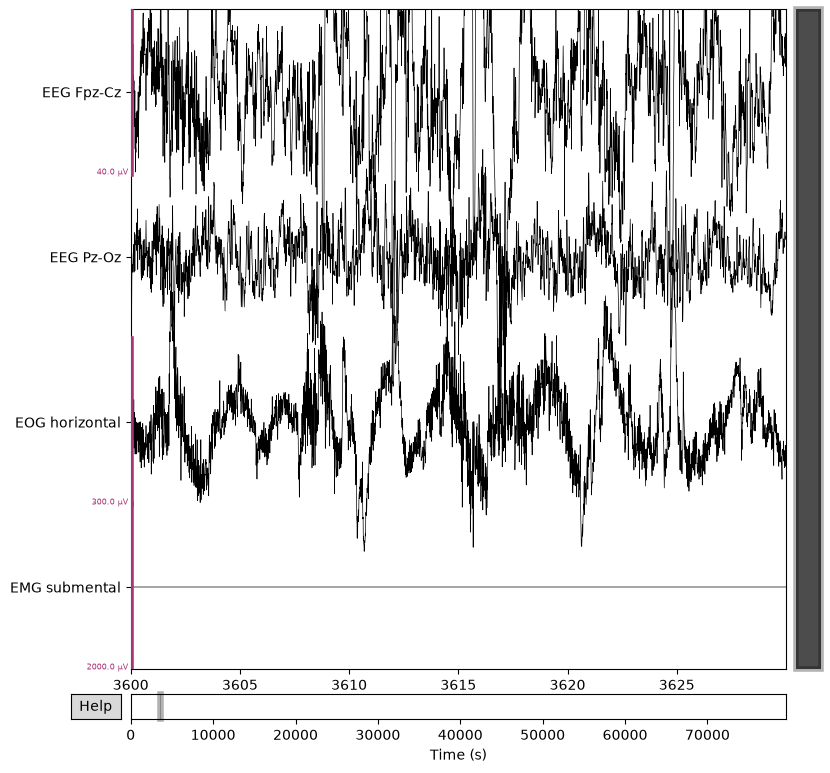

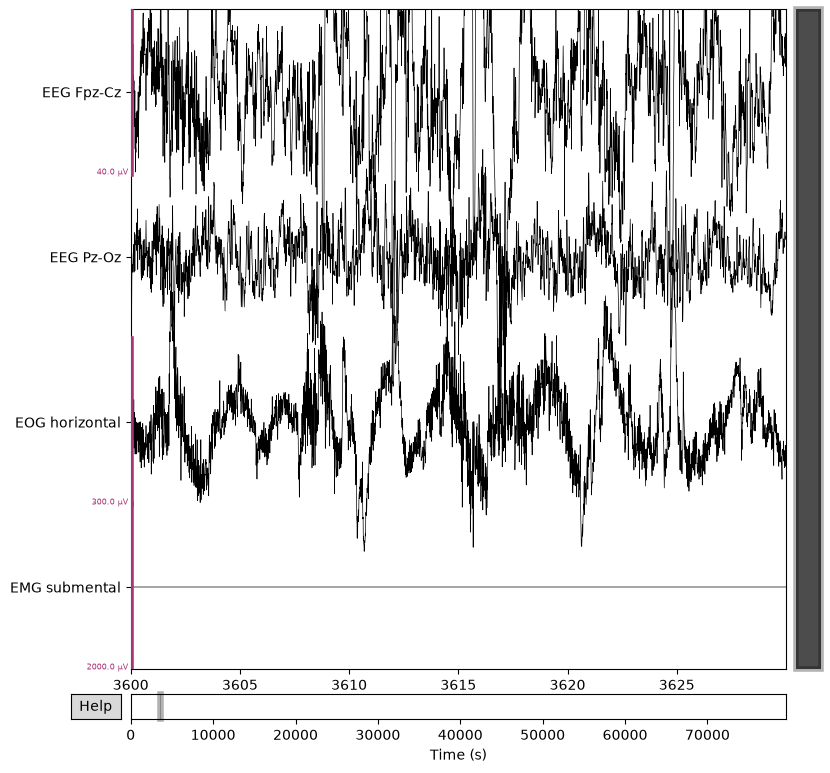

In [4]:
# 只留下腦波、眼動、肌電（體溫和事件標記先不看），從第 3600 秒開始畫 30 秒
fig = raw.copy().pick(["eeg", "eog", "emg"]).plot(start=3600, duration=30, show=False)
fig

For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


/var/folders/qv/tvnfffyn2jv_gfygw9g7zy7m0000gn/T/ipykernel_46876/3082708957.py:2: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  fig = raw.copy().pick(["eeg", "eog", "emg"]).plot(


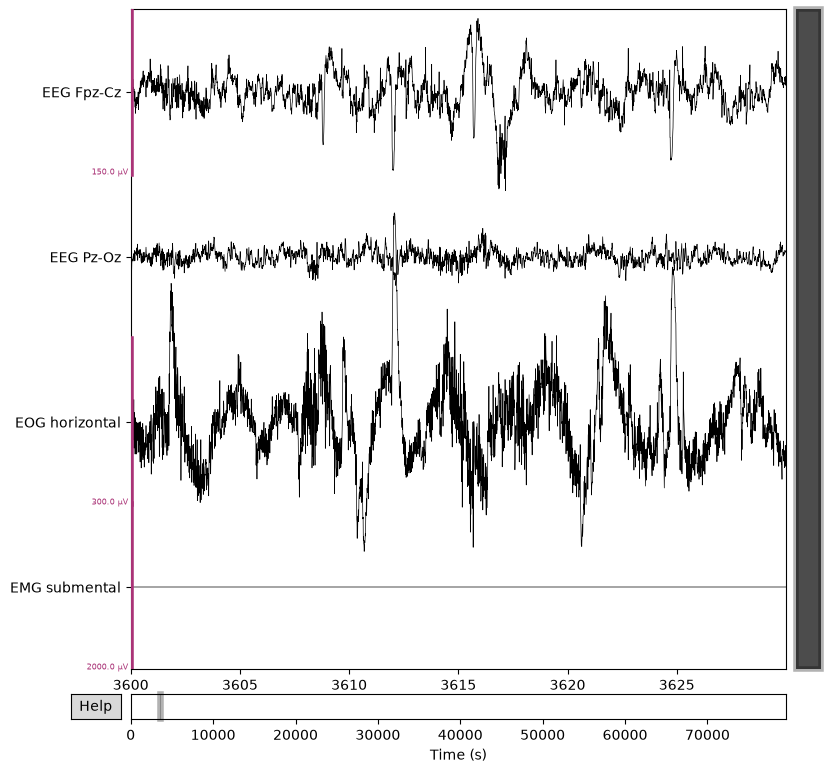

In [5]:
# 把 EEG 的比例尺放大到 75 微伏（µV），讓大振幅的慢波留在自己的跑道裡
fig = raw.copy().pick(["eeg", "eog", "emg"]).plot(
    start=3600, duration=30,
    scalings=dict(eeg=75e-6),   # e-6 代表「乘以百萬分之一」，也就是把微伏換算成伏特
    show=False,
)
fig

In [6]:
# 33 歲受試者的 Hypnogram 檔路徑
hyp_young = "../data/physionet-sleep-data/SC4001EC-Hypnogram.edf"

# 讀進專家標記的睡眠分期
annot = mne.read_annotations(hyp_young)

# 把註記接到腦波資料上
raw.set_annotations(annot, emit_warning=False)

# 列出所有出現過的標記種類（set 會自動去掉重複的）
print(set(annot.description))


{'Sleep stage 3', 'Sleep stage R', 'Sleep stage 1', 'Sleep stage W', 'Sleep stage 2', 'Sleep stage ?', 'Sleep stage 4'}


In [7]:
# 算作「睡著」的標記
sleep_stages = ["Sleep stage 1", "Sleep stage 2", "Sleep stage 3", "Sleep stage 4", "Sleep stage R"]

# 把所有「睡著」標記的開始時間收集起來（單位：秒）
sleep_onsets = [onset for onset, desc in zip(annot.onset, annot.description) if desc in sleep_stages]

# 第一個和最後一個
first_sleep = sleep_onsets[0]
last_sleep = sleep_onsets[-1]

print(first_sleep / 3600, last_sleep / 3600)   # 換算成小時

8.508333333333333 14.475


In [8]:
# 從「第一次睡著前 30 分鐘」切到「最後一段睡眠後 30 分鐘」（單位：秒）
raw.crop(tmin=first_sleep - 30 * 60, tmax=last_sleep + 30 * 60)

# 確認裁切後還剩幾小時
print(raw.times[-1] / 3600)

6.966666666666667


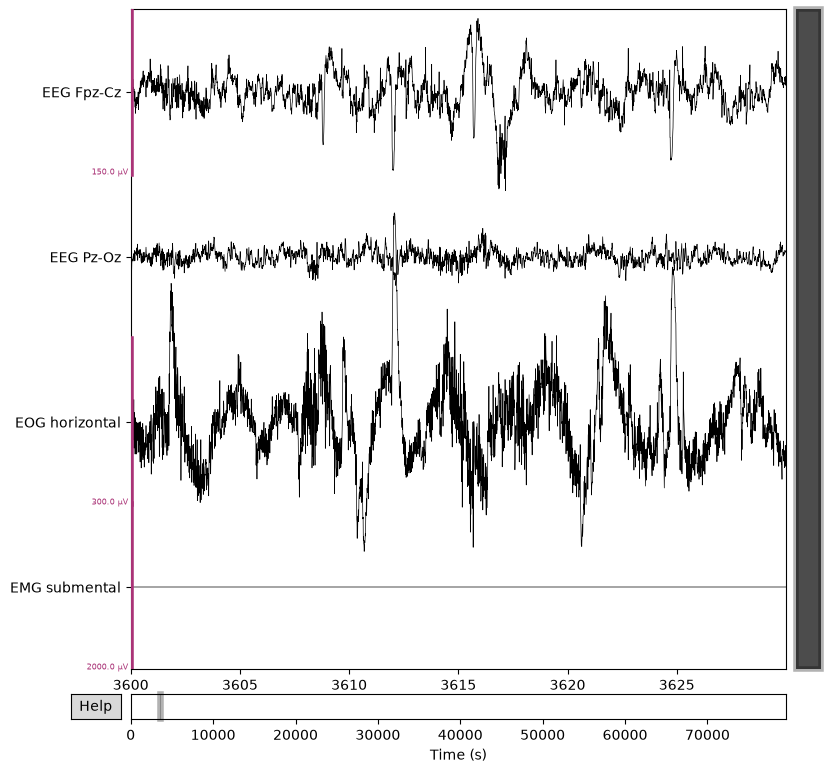

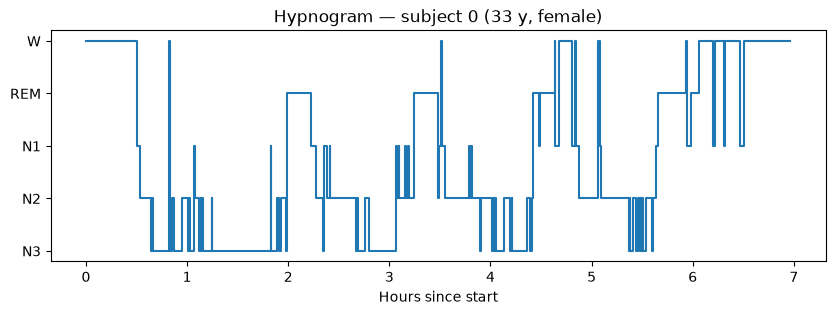

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 每個睡眠階段在圖上的高度：清醒最高，深睡最低
stage_y = {
    "Sleep stage W": 5,
    "Sleep stage R": 4,
    "Sleep stage 1": 3,
    "Sleep stage 2": 2,
    "Sleep stage 3": 1,   # 舊標準的第 3 期
    "Sleep stage 4": 1,   # 舊標準的第 4 期
}
# 收集每一段的「開始、結束」時間和高度，畫成階梯狀
times, heights = [], []
for onset, duration, desc in zip(raw.annotations.onset, raw.annotations.duration, raw.annotations.description):
    if desc in stage_y:                         # 跳過 "Sleep stage ?" 這種無法判讀的段落
        start = onset - raw.first_time          # 換算成「從裁切起點開始算」的秒數
        times += [start, start + duration]      # 這一段的開始和結束
        heights += [stage_y[desc]] * 2          # 開始和結束都是同一個高度

# 畫圖：橫軸換算成小時
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(np.array(times) / 3600, heights)
ax.set_yticks([1, 2, 3, 4, 5], ["N3", "N2", "N1", "REM", "W"])
ax.set_xlabel("Hours since start")
ax.set_title("Hypnogram — subject 0 (33 y, female)")
plt.show()

In [10]:
# 定義一個函數：輸入 PSG 和 Hypnogram 的路徑，輸出裁切好的夜間資料
def load_night(psg_path, hyp_path):
    raw = mne.io.read_raw_edf(psg_path, verbose="error")          # 讀腦波（verbose="error" 讓它不要印一堆訊息）
    raw.set_channel_types({"EOG horizontal": "eog", "EMG submental": "emg",
                           "Resp oro-nasal": "resp", "Temp rectal": "misc", "Event marker": "misc"})
    annot = mne.read_annotations(hyp_path)                              # 讀專家的睡眠分期
    raw.set_annotations(annot, emit_warning=False)
    onsets = [o for o, d in zip(annot.onset, annot.description) if d in sleep_stages]
    raw.crop(tmin=onsets[0] - 30 * 60, tmax=onsets[-1] + 30 * 60)  # 睡眠前後各留 30 分鐘
    return raw                                                     # 把處理好的資料交出去

In [11]:
# 85 歲受試者（第 64 位）的檔案
raw_old = load_night("../data/physionet-sleep-data/SC4641E0-PSG.edf",
                     "../data/physionet-sleep-data/SC4641EP-Hypnogram.edf")
print(raw_old.times[-1] / 3600)

10.583333333333334


/var/folders/qv/tvnfffyn2jv_gfygw9g7zy7m0000gn/T/ipykernel_46876/4249152050.py:4: RuntimeWarning: The unit for channel(s) Event marker, Temp rectal has changed from V to NA.
  raw.set_channel_types({"EOG horizontal": "eog", "EMG submental": "emg",


In [15]:
# 定義函數：把一個人的夜間資料畫在指定的位置（ax）上
def plot_hypnogram(raw, ax, title):
    times, heights = [], []
    for onset, duration, desc in zip(raw.annotations.onset, raw.annotations.duration, raw.annotations.description):
        if desc in stage_y:
            start = onset - raw.first_time
            times += [start, start + duration]
            heights += [stage_y[desc]] * 2
    ax.plot(np.array(times) / 3600, heights)
    ax.set_yticks([1, 2, 3, 4, 5], ["N3", "N2", "N1", "REM", "W"])
    ax.set_title(title)                      # 圖的標題要用哪一個投入口？

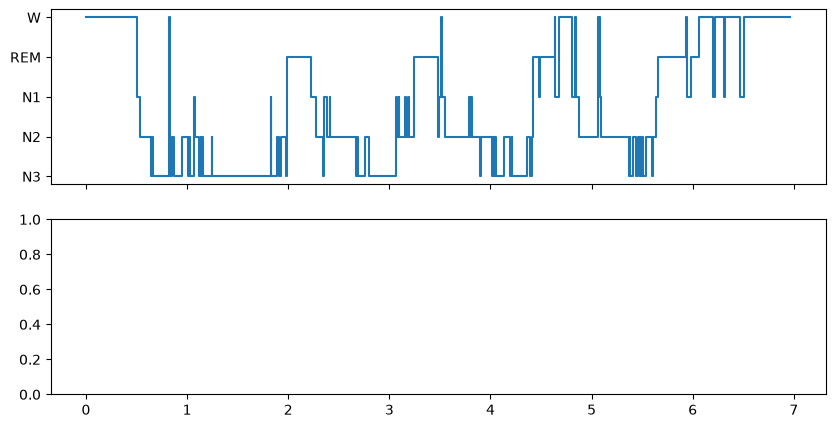

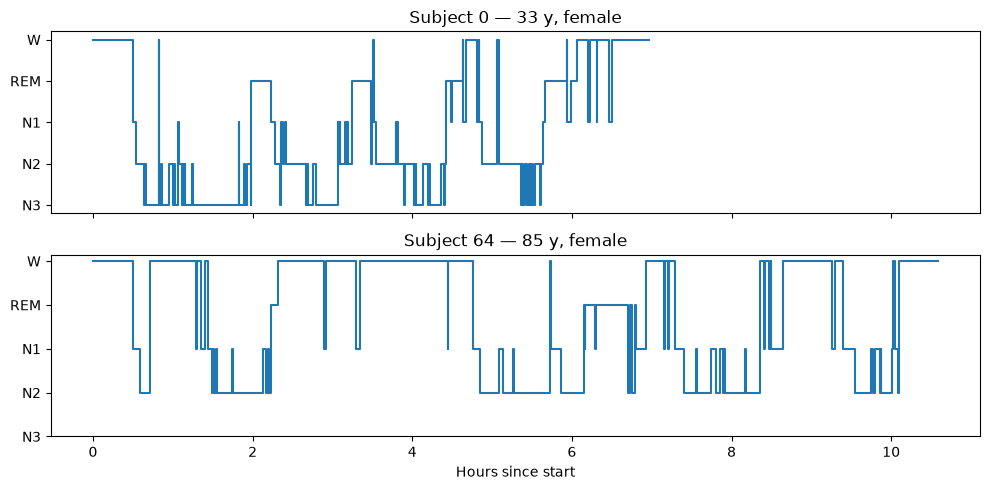

In [16]:
# 建立 2 列 × 1 欄的圖；sharex=True 讓上下共用同一條時間軸，比較才公平
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

plot_hypnogram(raw, axes[0], "Subject 0 — 33 y, female")
plot_hypnogram(raw_old, axes[1], "Subject 64 — 85 y, female")
axes[1].set_xlabel("Hours since start")

plt.tight_layout()                         # 自動調整間距，避免文字重疊
fig.savefig("../figures/02_hypnogram_young_vs_old.png", dpi=150)
plt.show()

In [17]:
import pandas as pd

# 把舊標準的標記對應到新標準的名稱
names = {
    "Sleep stage W": "W",
    "Sleep stage 1": "N1",
    "Sleep stage 2": "N2",
    "Sleep stage 3": "N3",    # 舊的第 3 期 → 新標準叫什麼？
    "Sleep stage 4": "N3",    # 舊的第 4 期 → 新標準叫什麼？
    "Sleep stage R": "REM",
}

# 定義函數：輸入一個人的夜間資料，輸出各項睡眠指標
def sleep_stats(raw):
    # 1. 累加每個階段的總分鐘數
    minutes = {"W": 0, "N1": 0, "N2": 0, "N3": 0, "REM": 0}
    for desc, dur in zip(raw.annotations.description, raw.annotations.duration):
        if desc in names:
            minutes[names[desc]] += dur / 60          # 秒換算成分鐘

    # 2. 總睡眠時間（TST）＝ 所有「睡著」階段加起來
    tst = minutes["N1"] + minutes["N2"] + minutes["N3"] + minutes["REM"]

    # 3. 醒來次數：從「睡著」變成「清醒」算一次
    seq = [names[d] for d in raw.annotations.description if d in names]
    awakenings = sum(1 for a, b in zip(seq, seq[1:]) if a != "W" and b == "W")

    # 4. 整理成結果（round 是四捨五入到小數點後一位）
    result = {k: round(v, 1) for k, v in minutes.items()}
    result["TST (min)"] = round(tst, 1)
    result["N3 %"] = round(minutes["N3"] / tst * 100, 1)
    result["REM %"] = round(minutes["REM"] / tst * 100, 1)
    result["Awakenings"] = awakenings
    return result

In [18]:
# 把兩個人的指標並排成一張表
table = pd.DataFrame({
    "33 y": sleep_stats(raw),
    "85 y": sleep_stats(raw_old),
})
table.to_csv("../figures/02_sleep_stats.csv")   # 存成 CSV，Excel 也能打開
table

,33 y,85 y
W,91.5,315.5
N1,29.0,89.5
N2,125.0,191.0
N3,110.0,0.0
REM,62.5,39.0
TST (min),326.5,319.5
N3 %,33.7,0.0
REM %,19.1,12.2
Awakenings,11.0,18.0


## Observations

Values are from `02_sleep_stats.csv` (one night per participant; wake minutes include the 30-min margins before and after sleep).

1. **Total sleep time was similar, but efficiency was not.** Both participants slept about 5.4 h (TST 326.5 vs 319.5 min), yet the 85-year-old spent 315.5 min awake versus 91.5 min for the 33-year-old, including one continuous awakening of about 1.5 h.
2. **Deep sleep was absent in the older participant.** N3 accounted for 33.7% of sleep in the 33-year-old, concentrated in the first two hours, but 0% in the 85-year-old, whose deepest stage was N2.
3. **Sleep was more fragmented and REM was reduced.** The 85-year-old had more awakenings (18 vs 11) and a lower REM proportion (12.2% vs 19.1%), with one main REM period instead of about five recurring cycles.

*Limitation:* This is a comparison of two individuals and illustrates, rather than establishes, age-related patterns. Because N3 scoring requires slow waves above 75 µV and slow-wave amplitude declines with age, visual scoring may underestimate deep sleep in older adults; Level 3 examines delta power directly.
